<a href="https://colab.research.google.com/github/babessell1/GWC_Test/blob/main/SineInteraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
def sine_wave(x,                        # 1-D positions where we’ll evaluate
              amplitude=1.0,            # peak value A
              phase_deg=0.0,            # phase offset in *degrees*
              displacement=0.0,         # speaker position shift Δx
              wavelength=1.0):          # λ  (defaults to 1 “unit”)
    """
    Return y(x) = A·sin[k·(x - Δx) + φ] for the array of x values provided.

    Args
    ----------
    x : np.ndarray
        Coordinate array at which to evaluate the wave.
    amplitude : float
        Peak value A.
    phase_deg : float
        Phase offset φ in *degrees* (easier for sliders / intuition).
    displacement : float
        Source’s physical shift Δx along the +x axis.
    wavelength : float
        Distance over which the wave completes one cycle (λ).
        Defaults to 1 so k = 2π is convenient.

    Returns
    -------
    y : np.ndarray
        The wave evaluated at every x.
    """
    # Convet the phase from deg to rad (numpy expects radians)
    phase_rad = np.deg2rad(np.float128(phase_deg))

    # convert wavelength to wave number
    k = 2 * np.pi / wavelength

    # core formula A * sin[ k(x -dx) + phi ]
    y = amplitude * np.sin( k*(x - displacement) + phase_rad )

    return y


In [ ]:
import numpy as np

x = np.array([1, 20 , 3, 4, 5])
A = 2
phase = 30
disp = 10
wl = 1
sine_wave(x, A, phase, disp, wl)

array([1., 1., 1., 1., 1.], dtype=float128)

In [ ]:
import numpy as np

wavelength = 2*np.pi
x = np.linspace(0, 4*wavelength, 1000)
y = sine_wave(x)

In [ ]:
dict_ = {
    'one': 2,
    'two': 4,
    'three': 6
}
dict_['two']
dict_

{'one': 2, 'two': 4, 'three': 6}

In [ ]:
dict_["four"] = 4
dict_["four"]

4

(0.0, 4.0)

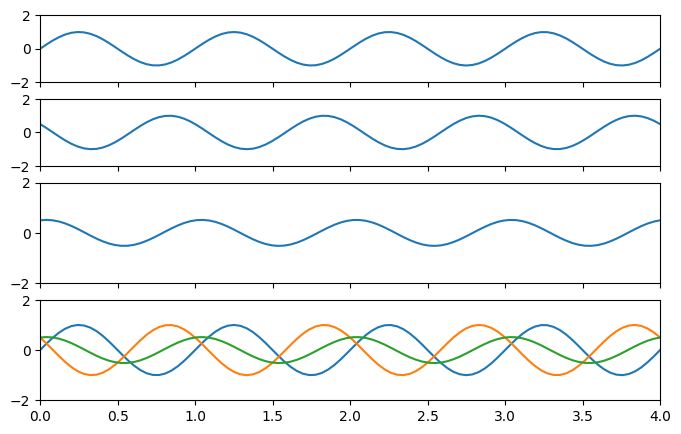

In [ ]:
import matplotlib.pyplot as plt

wavelength = 1
x = np.linspace(0, 4*wavelength, 100)  # grid of x values (for each x, plot y)
y1 = sine_wave( # get each y value for each x postion in the first speaker
    x,
    amplitude=1,
    phase_deg=0,
    displacement=0
)
y2 = sine_wave(  # ... and for the second speaker
    x,
    amplitude=1,
    phase_deg=150,
    displacement=0
)
ratio = 1.5  # since super position can be larger than the other two plots, allow the plot to be taller by a set amount

fig, ax = plt.subplots(  # initialize the plot
    nrows=4,  # four rows: speaker 1, speaker 2, superposition, then all together
    ncols=1,  # only one column (stack the plots on top of eachother, not next to eachother)
    sharex=True,  # share x axis to make sure the x values are all perfectly lined up with eachother
    figsize=(8,5),  # set the size of the plot
    gridspec_kw={"height_ratios": [1,1,ratio,ratio]})  # set the plot heights relative to eachother

# speaker 1 plot
ax[0].plot(x, y1)
ax[0].set_ylim(top=2, bottom=-2)
ax[0].set_xlim(left=0., right=4*wavelength)

# speaker 2 plot
ax[1].plot(x, y2)
ax[1].set_ylim(top=2, bottom=-2)
ax[1].set_xlim(left=0., right=4*wavelength)

# superpositon plot
ax[2].plot(x, y1+y2)
ax[2].set_ylim(top=2, bottom=-2)
ax[2].set_xlim(left=0., right=4*wavelength)

# all together
ax[3].plot(x, y1)
ax[3].plot(x, y2)
ax[3].plot(x, y1+y2)
ax[3].set_ylim(top=2, bottom=-2)
ax[3].set_xlim(left=0., right=4*wavelength)

In [ ]:
for ax_num, y_array in enumerate([y1, y2, y1+y2]):
  print("-----------------------------")
  print(ax_num)

-----------------------------
0
-----------------------------
1
-----------------------------
2


In [ ]:
import matplotlib.ticker as mtick

def plot_waves(
    A1, phase1_deg, dx1,
    A2, phase2_deg, dx2,
    wavelength: float = 1.0
):
  """
  Plot two 1D sine waves and their linear superposition.

  Three stacked plots:
    1. Speaker 1
    2. Speaker 2
    3. Combined (y1 + y2)

  Parameters
  ---------

  A1 : float
    Amplitude of speaker 1 (peak value)

  phase1_deg : float
    Phase offset phi **in degrees** for speaker 1

  dx1 : float
    Physical displacement of speaker 1

  A2: float
    Amplitude of speaker 2

  phase2_deg : float
    Phase offset for speaker 2

  dx2 : float
    physical displacement of speaker 2

  wavelength : float, optional
    wavelength lambda. Defaults to 1.0 (so k = k = 2*pi). Must be postive

  Notes
  ----
  **Linear superposition** - loss free, linear medium
  ** Common frequency - both sources share the same exact angular frequnecy
  ** No walls, floors, or objects to bounce the sound

  Examples
    --------
    Plot two waves with equal amplitude that are 180° out of phase
    (complete destructive interference):

    >>> plot_waves(A1=1, phase1_deg=0,   dx1=0,
    ...            A2=1, phase2_deg=180, dx2=0)

    Demonstrate constructive interference by setting both phase
    offsets to 0° (crests and troughs align):

    >>> plot_waves(A1=1, phase1_deg=0, dx1=0,
    ...            A2=1, phase2_deg=0, dx2=0)
  """
  # 1. Build an x-axis grid ()
  x = np.linspace(0, 4*wavelength, 500)

  # 2. Generate each wave with our helper function
  y1 = sine_wave(x, amplitude=A1, phase_deg=phase1_deg,
                 displacement=dx1, wavelength=wavelength)

  y2 = sine_wave(x, amplitude=A2, phase_deg=phase2_deg,
                 displacement=dx2, wavelength=wavelength)

  # 3. now we have all x and y values.
  fig, ax = plt.subplots(
      ncols=1,
      nrows=4, # y1, y2, y1+y2 (superposition), all together
      sharex=True,
      figsize=(8,5),  # set the size of the plot
      gridspec_kw={"height_ratios": [1,1,ratio,ratio]}  # set the plot heights relative to eachother
  )

  # make ticks
  xticks = np.linspace(0, 4*wavelength, 17)
  colormap = ['darkseagreen', 'maroon', 'royalblue']

  # 4. set params for ax (data, limits)
  for ax_num, y_array in enumerate([y1, y2, y1+y2]):
    # enumerate assigns a counter to a list
    ax[ax_num].plot(x, y_array, color=colormap[ax_num])
    ax[ax_num].set_xlim(0, 4*wavelength)
    ax[ax_num].set_ylim(-2, 2)
    ax[ax_num].set_xticks(xticks)
    ax[ax_num].xaxis.set_major_formatter(
        mtick.FormatStrFormatter('%.2f')
    )
    ax[3].plot(x, y_array, color=colormap[ax_num])

  ax[3].set_xlim(0, 4*wavelength)
  ax[3].set_xticks(xticks)
  ax[2].set_ylim(-1e-15, 1e-15)


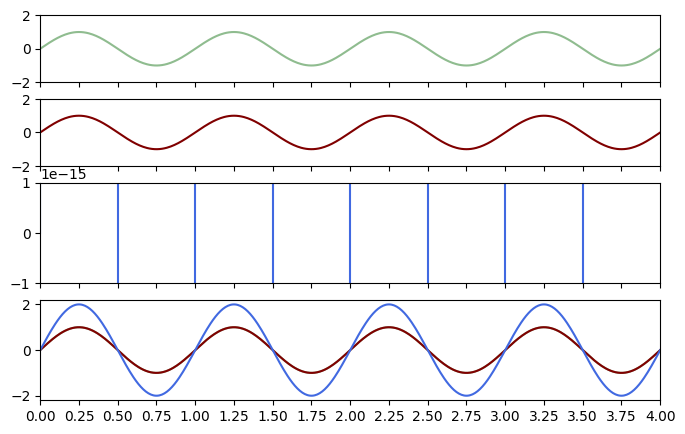

In [ ]:
plot_waves(
    1, 0, 0,
    1, 0, 0,
)

In [ ]:
import ipywidgets as widgets

In [ ]:
slider_layout = widgets.Layout(width="260px")
check_layout = widgets.Layout(width="130px")

controls = widgets.VBox([
    widgets.Label("Speaker 1"), # children
    widgets.FloatSlider(description="Amplitude",
                        value=1, min=0, max=10, step=0.1,
                        layout=slider_layout),
    widgets.FloatSlider(description="Phase (degrees)",
                        value=0, min=0, max=360, step=1,
                        layout=slider_layout),
    widgets.FloatSlider(description="Displacement",
                        value=0, min=0, max=4, step=0.1,
                        layout=slider_layout),
    widgets.Checkbox(description="(-)",
                     value=False, layout=check_layout),
    widgets.Label("Speaker 2"),
    widgets.FloatSlider(description="Amplitude",
                        value=1, min=0, max=10, step=0.1,
                        layout=slider_layout),
    widgets.FloatSlider(description="Phase (degrees)",
                        value=0, min=0, max=360, step=1,
                        layout=slider_layout),
    widgets.FloatSlider(description="Displacement",
                        value=0, min=0, max=4, step=0.1,
                        layout=slider_layout),
    widgets.Checkbox(description="(-)",
                     value=False, layout=check_layout)
])

def plot_wrapper(A1, phase1_deg, dx1, reverse1,
                 A2, phase2_deg, dx2, reverse2):
  phase1_effective = phase1_deg + (180 if reverse1 else 0)
  phase2_effective = phase2_deg + (180 if reverse2 else 0)
  plot_waves(A1, phase1_effective, dx1,
             A2, phase2_effective, dx2)

interactive_out = widgets.interactive_output(
    plot_wrapper,
    {
      "A1" : controls.children[1],
      "phase1_deg": controls.children[2],
      "dx1": controls.children[3],
      "reverse1": controls.children[4],
      "A2" : controls.children[6],
      "phase2_deg": controls.children[7],
      "dx2": controls.children[8],
      "reverse2": controls.children[9]
    }
)
interactive_out.layout = widgets.Layout(width="650px", height="450px")
display(
    widgets.HBox(
        [controls, interactive_out],
        layout=widgets.Layout(align_items='flex-start')
    )
)

In [ ]:
x = 0
i = 0
while x != 1.0:
    x += 0.1
    i += 1
    print(i)
    stop!

In [ ]:
print(0.1 + 0.2)
print(0.1 + 0.2 == 0.3)

0.30000000000000004
False


In [ ]:
a = 1.0000001
b = 1.0000000
print(a-b)

1.0000000005838672e-07


In [ ]:
x = 0.0
for i in range(1_000):
  x += 0.001
print(x, 'expected: ', 1.0)
print("diff: ", 1.0-x)

1.0000000000000007 expected:  1.0
diff:  -6.661338147750939e-16


In [ ]:
x = 0.0
for i in range(10_000):
  x += 0.0001
print(x, 'expected: ', 1.0)
print("diff: ", 1.0-x)

0.9999999999999062 expected:  1.0
diff:  9.381384558082573e-14


In [ ]:
x = 0.0
batch_size=100_000
increment = 0.00001
for i in range(batch_size):
  x += increment
print(x, 'expected: ', 1.0)
print("diff: ", 1.0-x)

# how can we make this more efficient without changing batch size or incrmenet?
x = np.float128(0.)
batch_size=100_000
increment = 0.00001
for i in range(batch_size):
  x += increment

print(x, 'expected: ', 1.0)
print("diff: ", 1.0-x)

# how can we make this more efficient without changing batch size or incrmenet?
x = 0.
c = 0. # compensator
batch_size=100_000
increment = 0.00001
for i in range(batch_size):
  y = x - c
  t = x + y
  c = (t-x) - y
  x = t

print(x, 'expected: ', 1.0)
print("diff: ", 1.0-x)

0.9999999999980838 expected:  1.0
diff:  1.91624494050302e-12
1.000000000000001273 expected:  1.0
diff:  -1.272961770715230756e-15
0.0 expected:  1.0
diff:  1.0


In [ ]:
print("smallest number our computer knows: ", sys.float_info.epsilon)

p = 1e-30 # probability of it being someone in my classes birthday today

# probability of it being someones birthday today and tomorrow?
print(p**2)

# probability of it being someones birthday 3 days in a row?
print(p**3)

# 10 days in a row
print(p**10)

# 100 day in a row
print(p**100)
# [np.log(p), np.log(p), np.log(p) ... 100 times ]
def probability(p, trials=100):
  import math
  print("naive: ", p**trials)
  sum_ = trials * np.log(p)
  print("stabilized: ", np.exp(sum_))

print(probability(p, 10))



smallest number our computer knows:  2.220446049250313e-16
1.0000000000000001e-60
1.0000000000000002e-90
1.0000000000000009e-300
0.0
naive:  1.0000000000000009e-300
stabilized:  1.0000000000000237e-300
None


In [ ]:
import sys

print(sys.float_info.epsilon)
print(1.0 + sys.float_info.epsilon == 1.0)

2.220446049250313e-16
False


Mini-Lesson Summary:

- Floating point numbers are not perfectly precise -- they are weird and sometimes infuriating :(

  - Repetition of addition and subtraction is BAD!

In [ ]:
180 if True else 0

180

In [ ]:
print(1.0 + 1e-17 == 1.0)

True


In [ ]:
list_ = ["a", "b", "b", "b", "b", "c", "c"]
list_2 = ['d', "d", "d", "b", "b", "a", "e"]
set(list_)
len(set(list_))

3

In [ ]:
import pandas as pd

df = pd.DataFrame({'A': list_, 'B': list_2})

In [ ]:
len(set(df["A"]))

3

In [ ]:
df["A"].nunique()

3

In [ ]:
df.pivot(columns="A")

B          
A    a    b    c
0    d  NaN  NaN
1  NaN    d  NaN
2  NaN    d  NaN
3  NaN    b  NaN
4  NaN    b  NaN
5  NaN  NaN    a
6  NaN  NaN    e